# 5. Segmentation Client avec K-Means


## 5.1 Préparation des données

Avant d’appliquer l’algorithme **K-Means**, il faut préparer les données RFM.

### Variables utilisées  
- **R (Recency)**  
- **F (Frequency)**  
- **M (Monetary)**  

### Standardisation  
Les variables R, F, M n'ont pas les mêmes échelles.  
Pour éviter qu’une variable domine les autres, on utilise **StandardScaler** :

\[
X_{scaled} = \frac{X - \mu}{\sigma}
\]

Résultat : un tableau normalisé contenant **R_scaled**, **F_scaled**, **M_scaled**, prêt pour K-Means.

---

## 5.2 Choix du nombre optimal de clusters

Le choix de **k** est crucial. Deux méthodes principales :

### 🔹 Méthode du coude (Elbow Method)
1. Exécuter K-Means pour k = 1 à 10  
2. Calculer l’inertie (WCSS)  
3. Tracer la courbe k vs inertie  
4. Le « coude » indique le meilleur k  

### 🔹 Silhouette Score
Mesure la qualité des clusters (de -1 à +1).

- +1 → clusters bien séparés  
- 0 → chevauchement  
- -1 → mauvais regroupement  

Le meilleur k = celui qui maximise la silhouette.

---

## 5.3 Entraînement K-Means

Une fois le k choisi (ex : k = 4) :

- Entraîner le modèle K-Means sur les données standardisées  
- Obtenir :  
  - Les centroïdes  
  - Le cluster attribué à chaque client  

---

## 5.4 Interprétation des clusters

Analyser chaque groupe en calculant les moyennes **R, F, M** (échelle originale).

### 💡 Profil Marketing par Cluster



| Cluster | Recency (R) | Frequency (F) | Monetary (M) | Interprétation                                   | Actions recommandées           |
|---------|-------------|---------------|--------------|-------------------------------------------------|-------------------------------|
| 0       | Faible      | Élevé         | Élevé        | **Champions** : clients récents, fidèles et rentables | Fidélisation, offres VIP       |
| 1       | Moyen       | Moyen         | Moyen        | **Clients réguliers** : clients engagés et stables    | Promotions personnalisées      |
| 2       | Élevé       | Faible        | Faible       | **At Risk** : clients en risque de départ              | Campagnes de réactivation      |
| 3       | Faible      | Faible        | Faible       | **Nouveaux clients** : clients récents avec faible activité | Offres de bienvenue            |
| 4       | Moyen       | Élevé         | Moyen        | **Potential Loyalist** : clients en croissance          | Encourager la fidélité         |
| 5       | Élevé       | Moyen         | Moyen        | **Can't Lose Them** : clients précieux à ne pas perdre | Actions de rétention ciblées  |




In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
import pandas as pd


from sklearn import metrics
from scipy.spatial.distance import cdist
import numpy as np


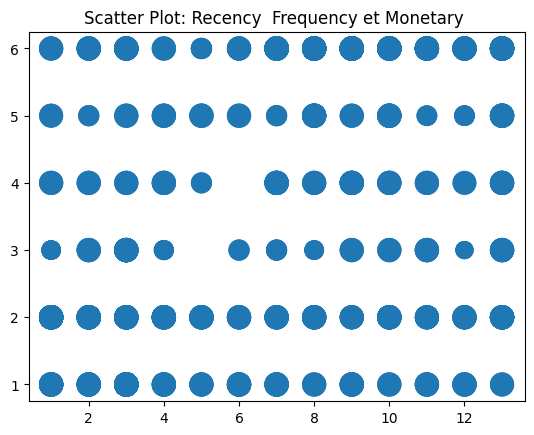

In [25]:
plt.scatter(tableRFM['Recency'], tableRFM['Frequency'], tableRFM['Monetary'], marker='o')


plt.title('Scatter Plot: Recency  Frequency et Monetary ')
plt.show()

In [26]:
# Supposons rfm_df avec colonnes 'Recency', 'Frequency', 'Monetary'
X = tableRFM[['Recency', 'Frequency', 'Monetary']]

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [27]:
distortions = []
inertias = []
mapping1 = {}
mapping2 = {}
K = range(1, 20)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42).fit(X)

    distortions.append(sum(np.min(cdist(X, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / X.shape[0])

    inertias.append(kmeanModel.inertia_)

    mapping1[k] = distortions[-1]
    mapping2[k] = inertias[-1]

Distortion values:
1 : 1954.529626430732
2 : 532.5370393767381
3 : 245.50675325934253
4 : 151.87900771502535
5 : 87.66451717820722
6 : 59.21982617066975
7 : 48.15016608065743
8 : 43.32199056759863
9 : 37.44336806576709
10 : 31.369864702384255
11 : 28.215251623759553
12 : 25.35608996079241
13 : 24.19618946965659
14 : 21.178182563690378
15 : 19.889863524866808
16 : 18.38490065349002
17 : 17.112285185812492
18 : 16.47833031769905
19 : 15.702157166567497


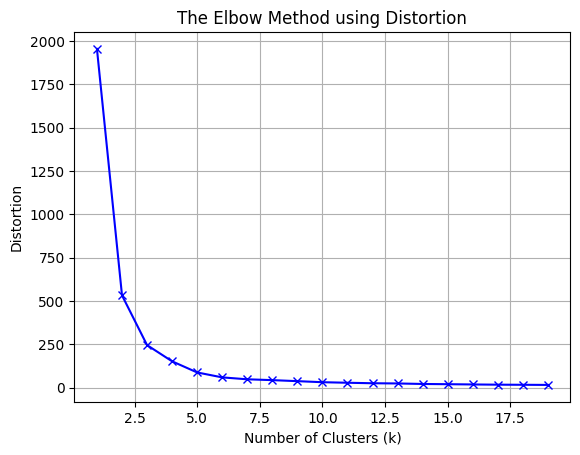

In [28]:
print("Distortion values:")
for key, val in mapping1.items():
    print(f'{key} : {val}')

plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.grid(True)
plt.title('The Elbow Method using Distortion')
plt.show()

Inertia values:
1 : 11004001.79680502
2 : 2998183.5316910353
3 : 1382203.0208500985
4 : 855078.8134355922
5 : 493551.2317133067
6 : 333407.6213408706
7 : 271085.4350341015
8 : 243902.80689558043
9 : 210806.16221026875
10 : 176612.3382744234
11 : 158851.86664176625
12 : 142754.78647926127
13 : 136224.54671416664
14 : 119233.16783357681
15 : 111979.9316450002
16 : 103506.99067914879
17 : 96342.16559612441
18 : 92772.99968864559
19 : 88403.14484777504


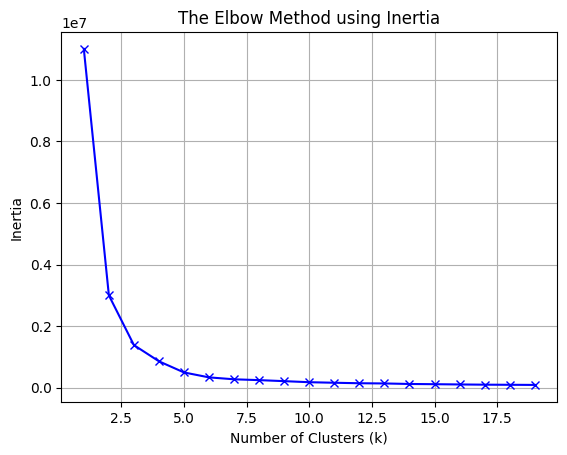

In [29]:
print("Inertia values:")
for key, val in mapping2.items():
    print(f'{key} : {val}')

plt.plot(K, inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.title('The Elbow Method using Inertia')
plt.show()

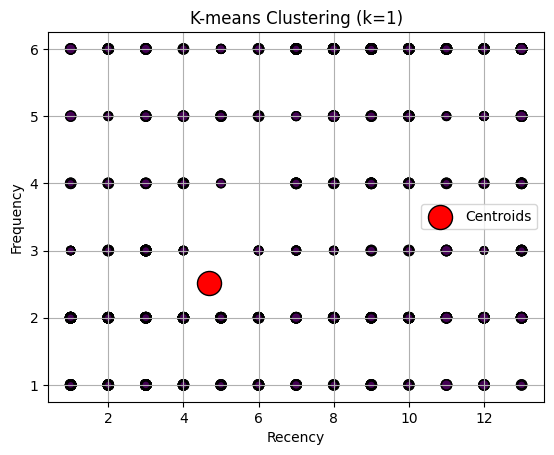

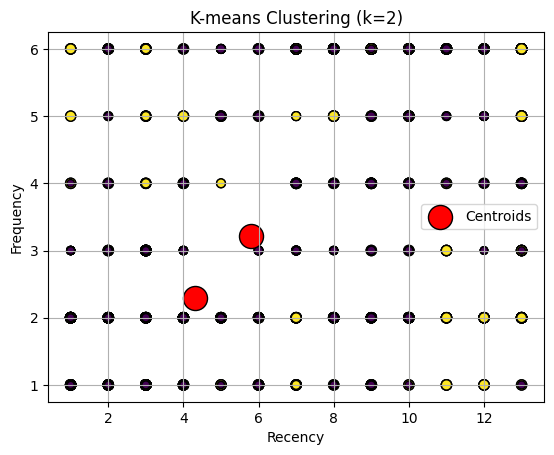

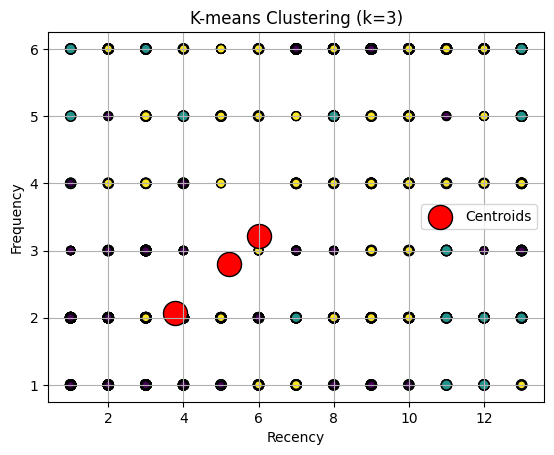

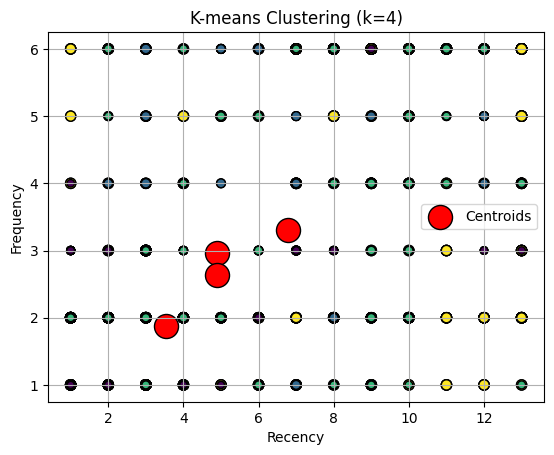

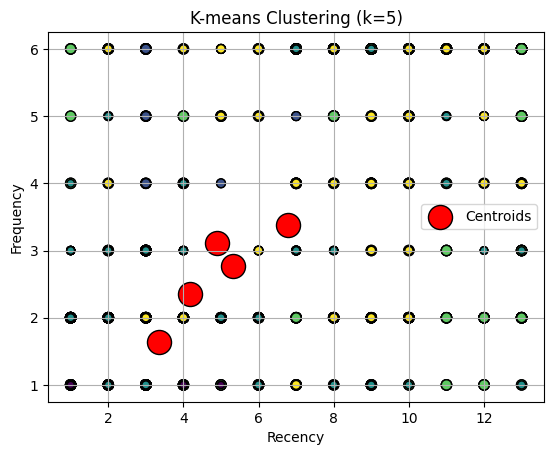

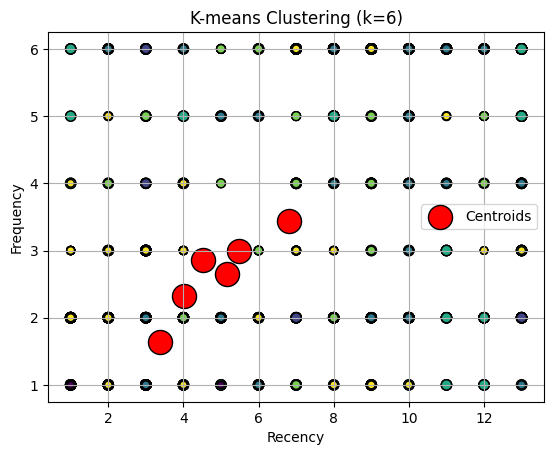

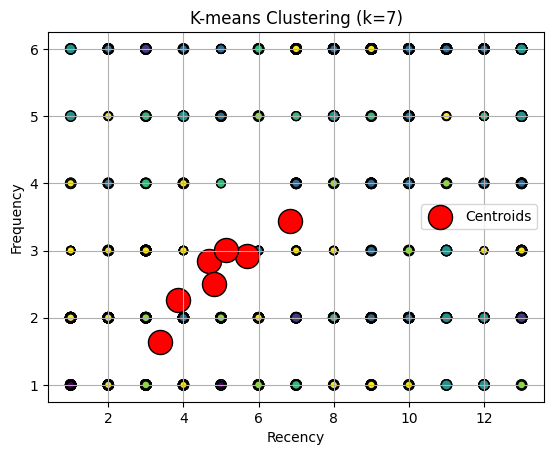

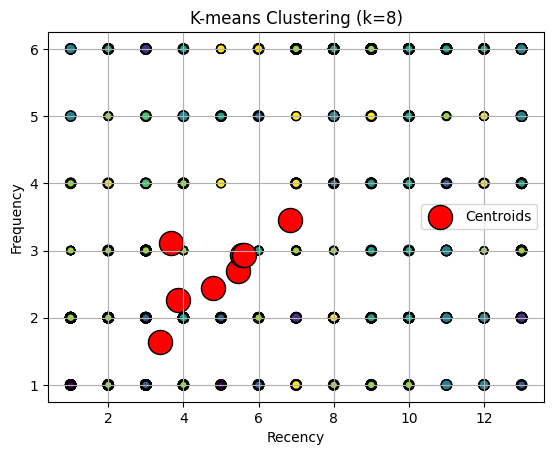

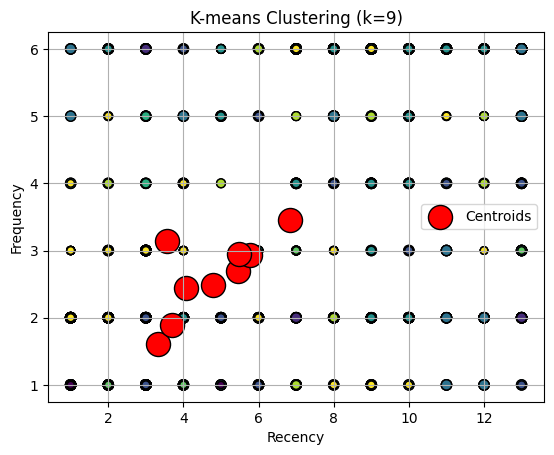

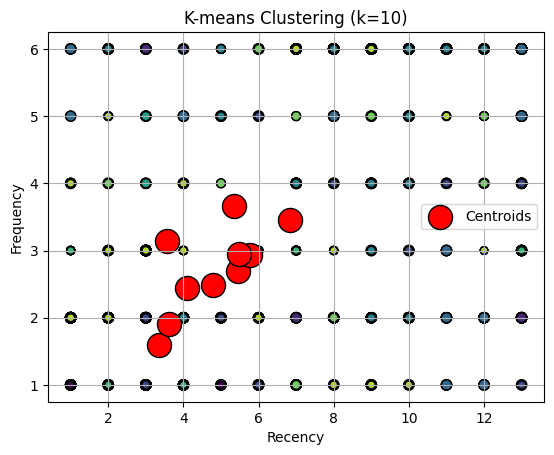

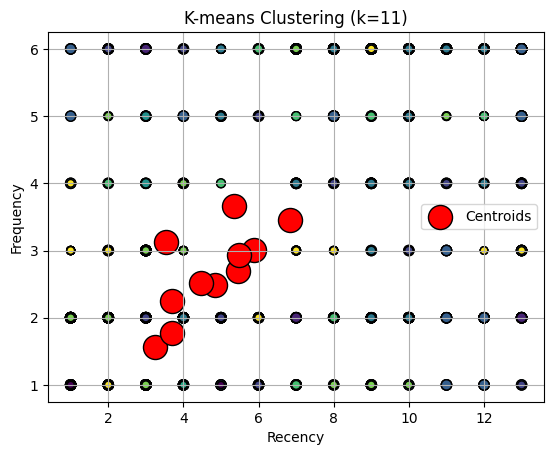

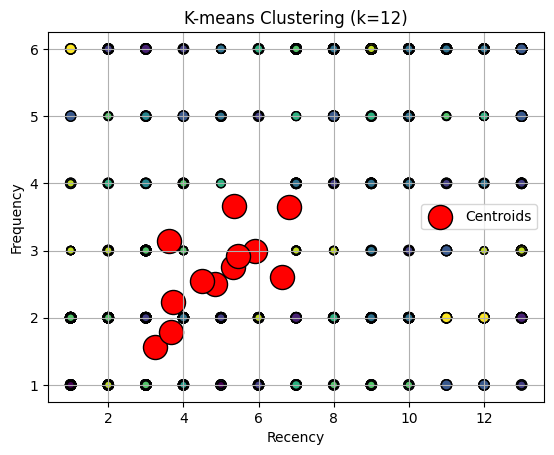

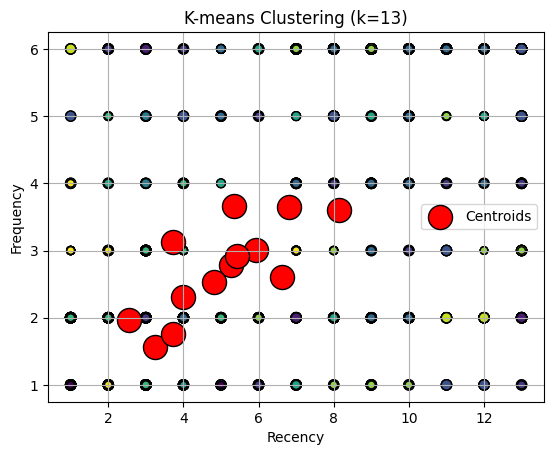

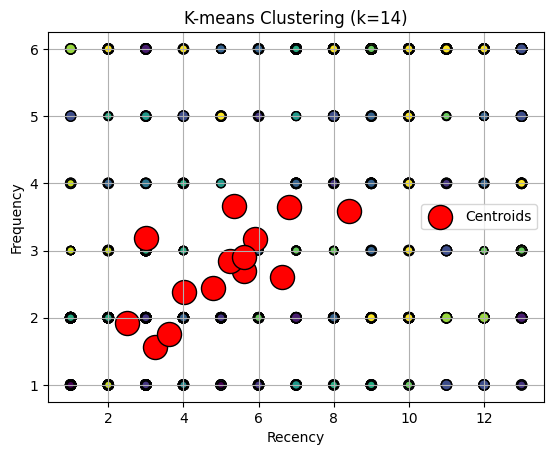

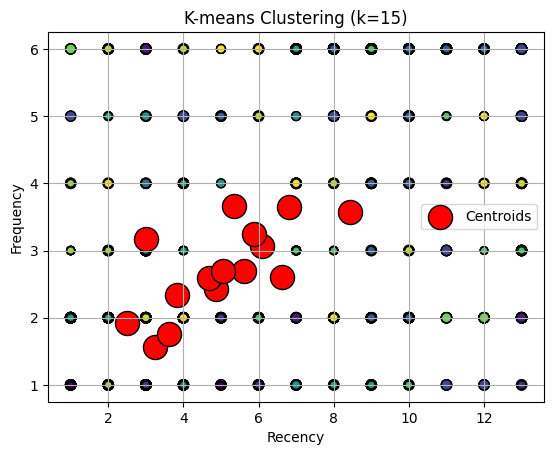

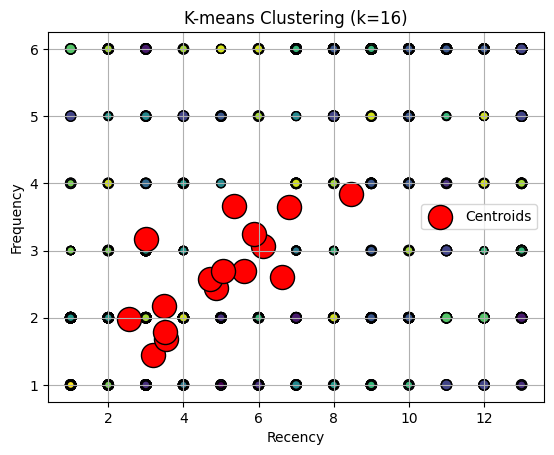

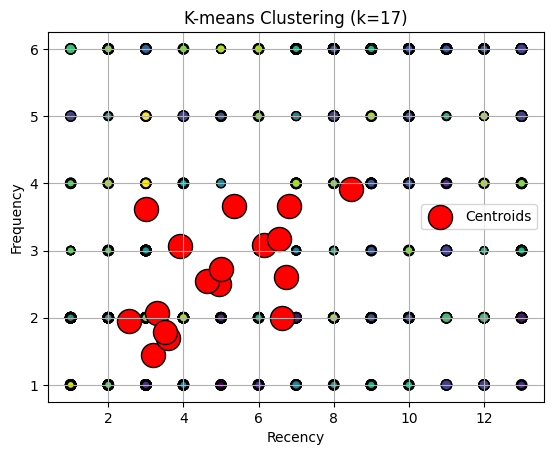

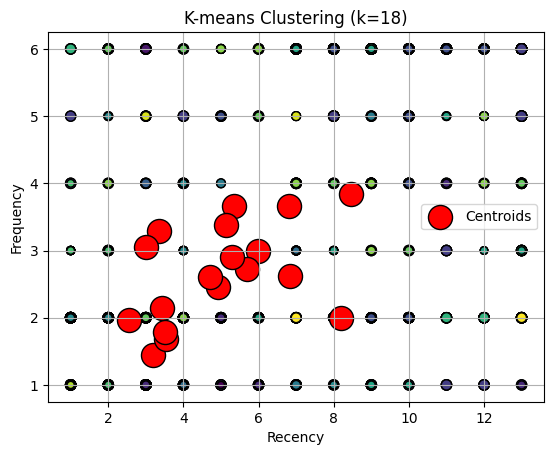

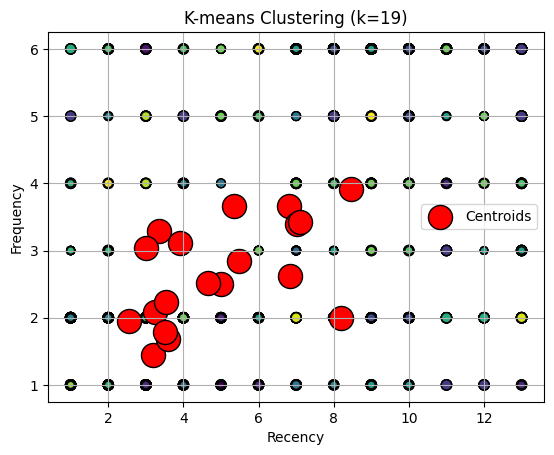

In [35]:
k_range = range(1, 20)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    y_kmeans = kmeans.fit_predict(X)

    plt.scatter(X['Recency'], X['Frequency'], s=X['Monetary']/5, c=y_kmeans, cmap='viridis', marker='o', edgecolor='k')
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                s=300, c='red', label='Centroids', edgecolor='k')
    plt.title(f'K-means Clustering (k={k})')
    plt.xlabel('Recency')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid()
    plt.show()

In [46]:
# Choix du k optimal est 5
k_opt = 10
for k in range(1, k_opt):
   kmeans = KMeans(n_clusters=k_opt, random_state=42)
   tableRFM['Cluster'] = kmeans.fit_predict(X_scaled)

# Moyennes par cluster (en valeurs originales)
   cluster_summary = tableRFM.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
   print("=================================================================================")
   print(f'K-means Clustering (k={k})')
   print(cluster_summary)
   print("=================================================================================")

K-means Clustering (k=1)
           Recency  Frequency    Monetary
Cluster                                  
0         2.649385   1.115993  131.790344
1        10.970732   5.229268  173.424305
2         2.840525   1.885553  242.726337
3         8.042213   1.639010  165.124003
4         7.204633   5.667954  161.461361
5         9.983806   1.939271  251.895901
6         9.582222   5.635556  270.897422
7         3.497368   2.095614  165.612956
8         2.987234   5.561702  217.812144
9         1.353276   1.907407  159.459929
K-means Clustering (k=2)
           Recency  Frequency    Monetary
Cluster                                  
0         2.649385   1.115993  131.790344
1        10.970732   5.229268  173.424305
2         2.840525   1.885553  242.726337
3         8.042213   1.639010  165.124003
4         7.204633   5.667954  161.461361
5         9.983806   1.939271  251.895901
6         9.582222   5.635556  270.897422
7         3.497368   2.095614  165.612956
8         2.987234   5.561

In [ ]:
vjhvjhv

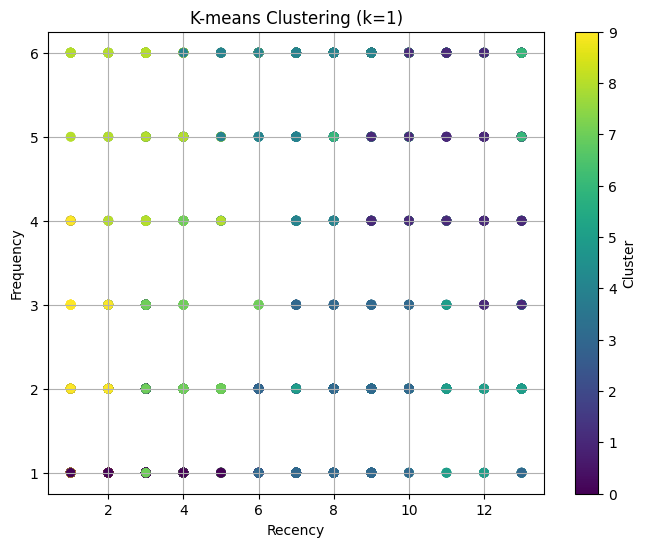

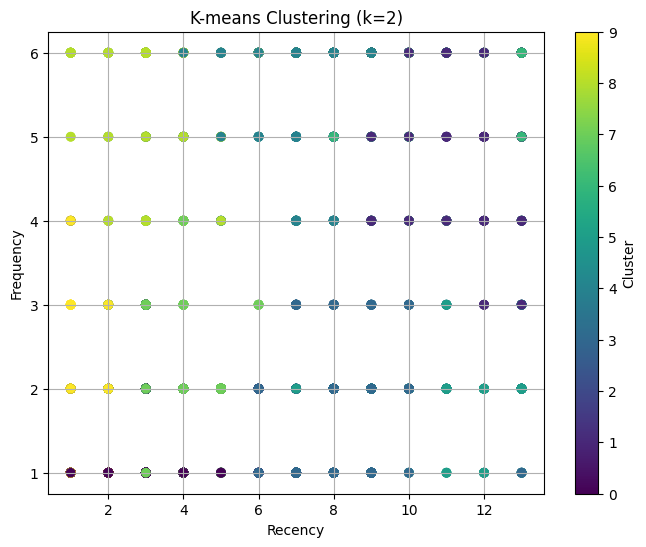

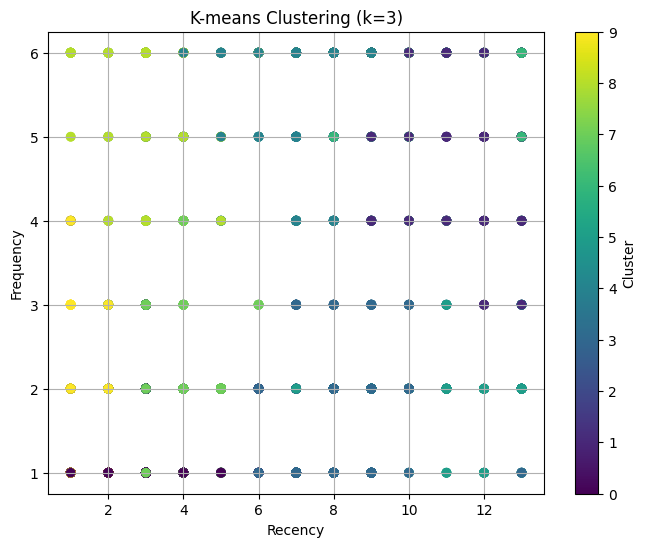

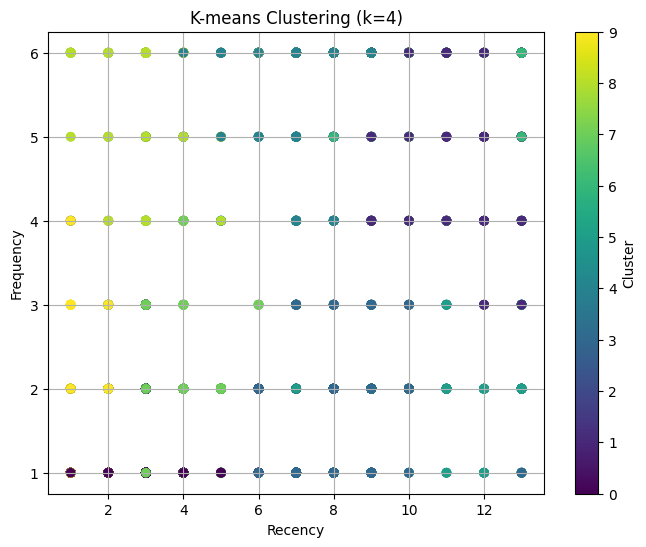

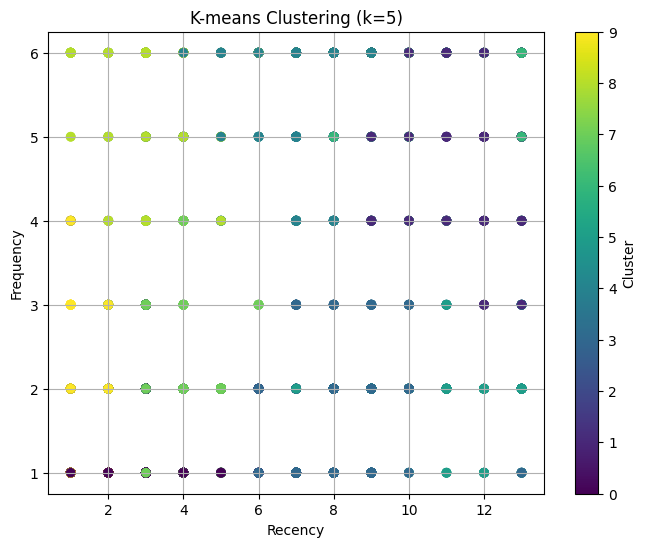

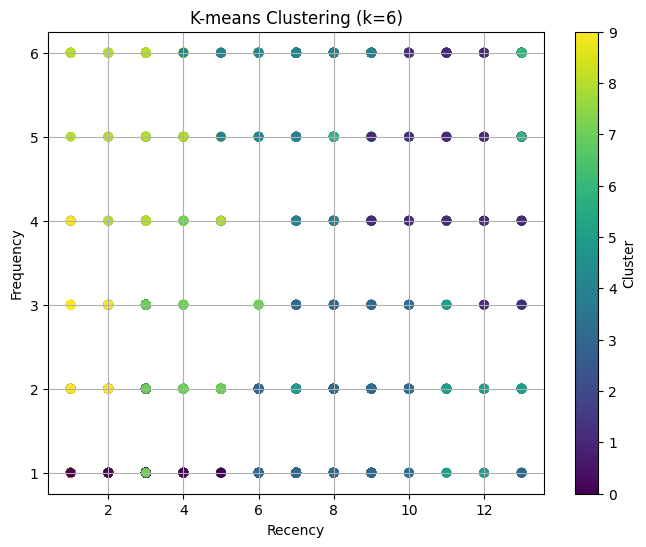

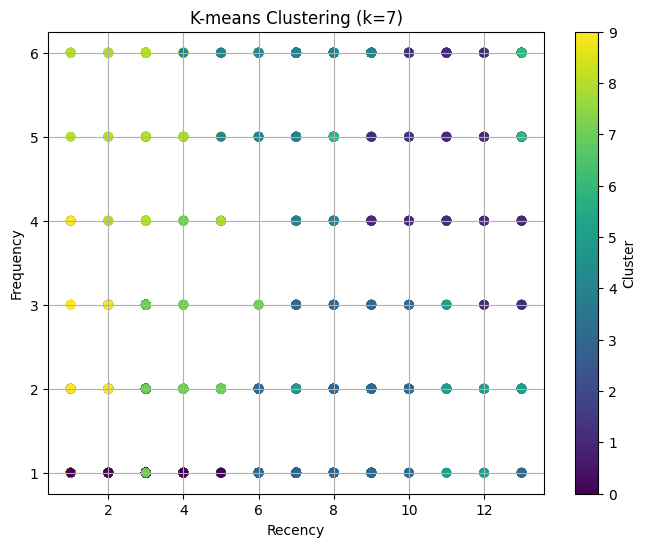

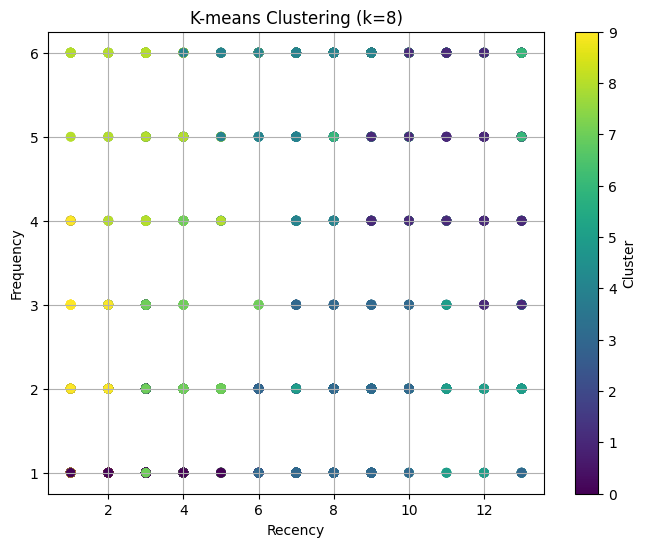

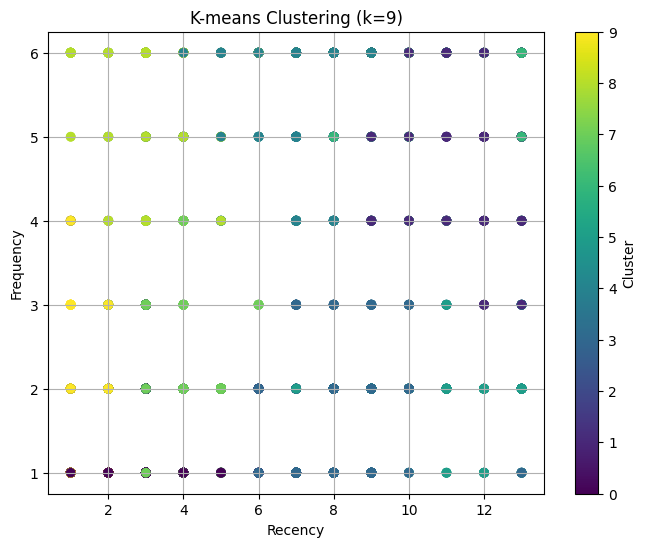

In [45]:
for k in range(1, k_opt):
  plt.figure(figsize=(8,6))

# scatter plot
  plt.scatter(
    tableRFM['Recency'],
    tableRFM['Frequency'],
    c=tableRFM['Cluster'],     # couleur automatique selon cluster
)
  plt.title(f'K-means Clustering (k={k})')
  plt.xlabel('Recency')
  plt.ylabel('Frequency')

  plt.colorbar(label='Cluster')
  plt.grid(True)
  plt.show()


In [47]:
# K optimale est 6
k_opt=6
kmeans = KMeans(n_clusters=k_opt, random_state=42)
tableRFM['Cluster'] = kmeans.fit_predict(X_scaled)

# Moyennes par cluster (en valeurs originales)
cluster_summary = tableRFM.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

In [48]:
#  Catégorisation automatique (faible/moyenne/haute) sur les moyennes de clusters
# -----------------------------
# On catégorise en utilisant quantiles sur les moyennes par cluster (pour stabilité)
def categorize_series(series):
    q1 = series.quantile(0.33)
    q2 = series.quantile(0.66)
    def cat(x):
        if x <= q1: return "faible"
        elif x <= q2: return "moyenne"
        else: return "haute"
    return series.apply(cat)

# appliquer sur cluster_summary moyennes (utiliser les colonnes moyennes)
cat_df = cluster_summary[['Recency','Frequency','Monetary']].copy()
cat_df = cat_df.apply(categorize_series)

# -----------------------------
# 8) Attribution des profils marketing
# -----------------------------
def assign_profile(row):
    r = row['Recency']
    f = row['Frequency']
    m = row['Monetary']
    # Règles simples ; adapte selon ton business
    if r == "faible" and f == "haute":
        return "⭐ Champions"
    if r == "faible" and f == "moyenne":
        return "Clients actifs"
    if r == "moyenne" and f == "faible":
        return "Occasionnels"
    if r == "moyenne" and f == "moyenne":
        return "Peu engagés"
    if r == "haute":
        return "🔥 Risque / Perdus"
    # fallback selon Monetary
    if m == "haute":
        return "Gros dépensiers"
    return "Autre"

profile_series = cat_df.apply(assign_profile, axis=1)
final_profile_table = pd.DataFrame({
    'Cluster': cat_df.index,
    'Recency': cat_df['Recency'],
    'Frequency': cat_df['Frequency'],
    'Monetary': cat_df['Monetary'],
    'Profil': profile_series
}).set_index('Cluster')

print("\nTableau final profils:")
print(final_profile_table)



Tableau final profils:
         Recency Frequency Monetary             Profil
Cluster                                               
0         faible    faible   faible              Autre
1          haute     haute   faible  🔥 Risque / Perdus
2        moyenne     haute  moyenne              Autre
3        moyenne    faible  moyenne       Occasionnels
4          haute   moyenne    haute  🔥 Risque / Perdus
5         faible   moyenne    haute     Clients actifs
